In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
selected_sensors = [
    "sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8", "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15", "sensor_17", "sensor_20"
]

In [3]:
train = pd.read_csv("../data/processed/train_FD001_processed.csv")
model_data = train[["engine_id", "cycle"] + selected_sensors + ["RUL"]].copy()
model_data.to_csv("../data/processed/FD001_selected_features.csv", index=False)

In [4]:
engine_ids = model_data["engine_id"].unique()
train_engines, val_engines = train_test_split.train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = model_data[model_data["engine_id"].isin(train_engines)].copy()
val_data = model_data[model_data["engine_id"].isin(val_engines)].copy()

In [5]:
print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print("Training rows:", len(train_data))
print("Validation rows:", len(val_data))

Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


In [6]:
features = ["cycle"] + selected_sensors

X_train = train_data[features]
y_train = train_data["RUL"]

X_val = val_data[features]
y_val = val_data["RUL"]


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [8]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)

In [9]:
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)

In [10]:
print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 32.54387340997973
Validation MAE: 25.1301073686816
Training RMSE: 42.3764218979544
Validation RMSE: 31.642480146853828


Linear regression (baseline) -> DONE

In [11]:
results = val_data.copy()

results["predicted_RUL"] = y_val_pred

results["error"] = (
    results["predicted_RUL"]
    - results["RUL"]
)

results["absolute_error"] = abs(results["error"])
results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,engine_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,RUL,predicted_RUL,error,absolute_error
16885,84,1,643.21,1582.28,1411.05,552.34,2388.13,9047.16,47.70,521.74,2388.17,8126.26,8.4379,393,38.69,266,144.241686,-121.758314,121.758314
16895,84,11,642.52,1591.73,1414.97,553.17,2388.13,9050.57,47.68,521.04,2388.16,8127.50,8.4334,394,38.77,256,139.886024,-116.113976,116.113976
16886,84,2,643.03,1590.29,1405.09,552.78,2388.11,9049.45,47.59,521.42,2388.21,8130.41,8.4355,391,38.86,265,151.167171,-113.832829,113.832829
16891,84,7,643.18,1592.68,1406.51,553.42,2388.09,9052.31,47.65,521.54,2388.13,8124.68,8.4577,393,38.79,260,147.027700,-112.972300,112.972300
16896,84,12,643.19,1583.14,1402.03,553.06,2388.10,9041.66,47.71,521.02,2388.10,8133.01,8.4633,394,38.75,255,142.106696,-112.893304,112.893304
16888,84,4,642.81,1583.83,1410.99,552.91,2388.16,9047.11,47.54,521.02,2388.15,8125.17,8.4267,392,38.80,263,150.662511,-112.337489,112.337489
16897,84,13,642.43,1593.97,1413.78,552.66,2388.12,9048.77,47.69,521.63,2388.11,8127.55,8.4428,393,38.89,254,143.133881,-110.866119,110.866119
16889,84,5,643.05,1590.42,1409.12,553.06,2388.09,9040.72,47.46,521.10,2388.14,8133.34,8.4131,395,38.88,262,151.546440,-110.453560,110.453560
16894,84,10,642.51,1588.42,1411.19,553.00,2388.15,9041.87,47.49,520.81,2388.10,8127.63,8.4668,392,38.90,257,148.238469,-108.761531,108.761531
16903,84,19,642.85,1589.71,1411.99,553.04,2388.10,9045.48,47.72,521.07,2388.16,8128.78,8.4318,393,38.92,248,139.483132,-108.516868,108.516868


In [12]:
engine_errors = (
    results
    .groupby("engine_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

engine_errors

engine_id
45    51.909716
84    51.233663
74    41.877895
77    34.855505
91    34.115766
1     27.064463
13    26.024177
19    25.131687
5     24.819508
23    24.368476
81    22.662805
54    19.911998
46    18.301400
78    17.881870
31    17.569992
11    17.416453
34    16.273180
71    15.996809
32    13.569063
40    13.499361
Name: absolute_error, dtype: float64

Analysis:
- most of the wrong predictions are much lower than the actual values
- the first cycles are the cycles with the largest errors
- why is there huge difference in prediction error between engine 45 and 40 (51 ->> 13)? 

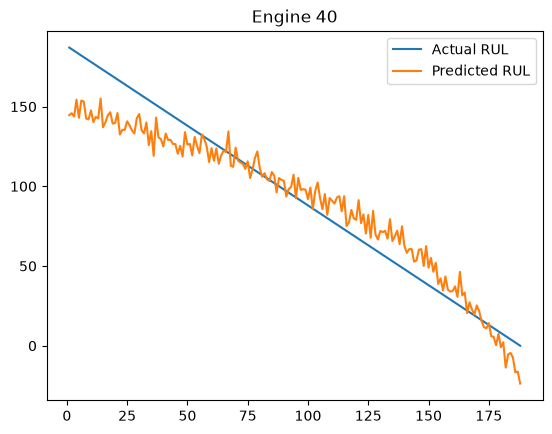

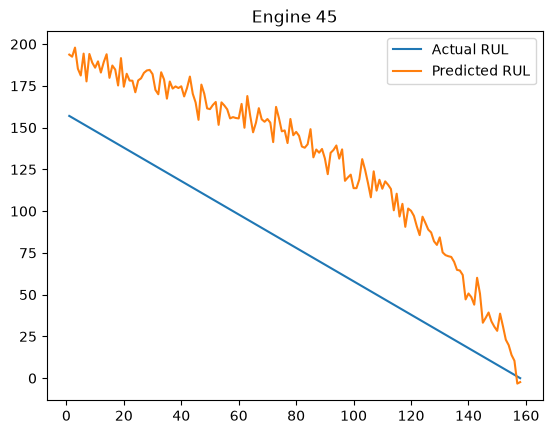

In [13]:
engine_40 = results[results["engine_id"] == 40]
engine_45 = results[results["engine_id"] == 45]

plt.plot(
    engine_40["cycle"],
    engine_40["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_40["cycle"],
    engine_40["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 40")
plt.show()
plt.plot(
    engine_45["cycle"],
    engine_45["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_45["cycle"],
    engine_45["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 45")
plt.show()


deduction from comparison between 40 and 45:
- engine 40 starts by underestimating RUL, then near the end it starts overestimating
- while engine 45 predicts that it has much more RUL than it actually does
- so the model predicts engine 45 is much more healthier than it actually is.
- it looks like early life is difficult to predict
- different engines have VERY different error patterns
- also, why is the model predicting RUL < 0 near the end? which isnt possible
- now, why is that so...

corrected error analysis: 
- Large errors occur especially during early/mid engine life, but their direction varies by engine. Some long-lived engines are underpredicted, while some shorter-lived engines are overpredicted.

Lets see if there is a similar error pattern between engine 45 and 84 (worst error engines) 

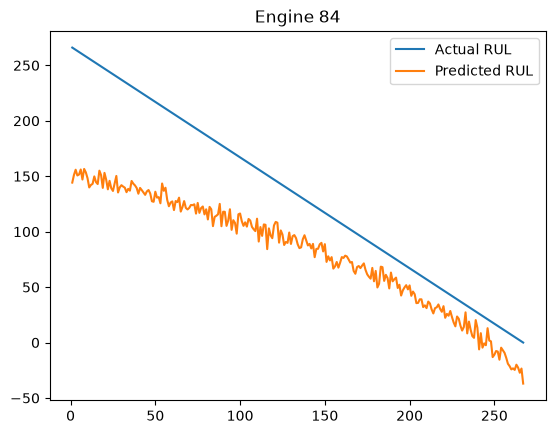

In [14]:
engine_84 = results[results["engine_id"] == 84]
plt.plot(
    engine_84["cycle"],
    engine_84["RUL"],
    label="Actual RUL"
)

plt.plot(
    engine_84["cycle"],
    engine_84["predicted_RUL"],
    label="Predicted RUL"
)

plt.legend()
plt.title("Engine 84")
plt.show()

Deduction from engine 45 vs 84:
- Again, early life is absurd, very difficult to predict
- its close to the actual results near the end
- but here it UNDERestimates the whole prediction , correction to the first conclusion

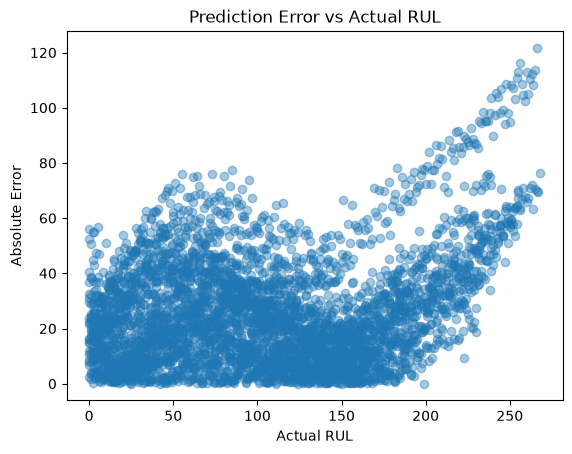

In [15]:
plt.scatter(results["RUL"], results["absolute_error"], alpha=0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Actual RUL")
plt.show()

Analysis:
- At higher RUL, the abs error is much more higher
- So it means at early stages the error is very high

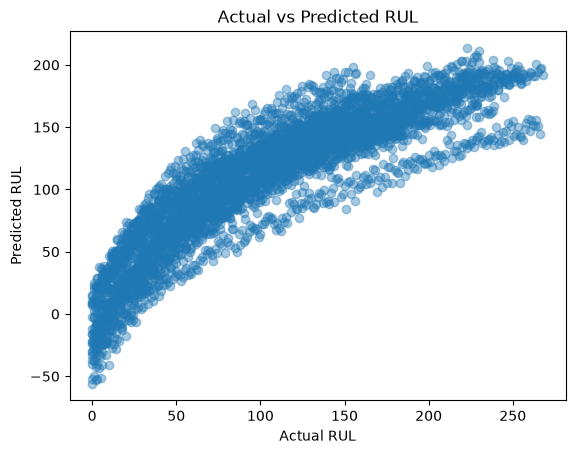

In [16]:
plt.scatter(y_val, y_val_pred, alpha=0.4)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

We'll try capping the RUL from 0 -> 125 since at high RUL the model fails absurdly to predict

In [17]:
RUL_CAP = 125

train_data["RUL_capped"] = train_data["RUL"].clip(upper=RUL_CAP)
val_data["RUL_capped"] = val_data["RUL"].clip(upper=RUL_CAP)

y_train_capped = train_data["RUL_capped"]
y_val_capped = val_data["RUL_capped"]

In [18]:
from sklearn.linear_model import LinearRegression

capped_model = LinearRegression()

capped_model.fit(
    X_train_scaled,
    y_train_capped
)
y_train_capped_pred = capped_model.predict(X_train_scaled)
y_val_capped_pred = capped_model.predict(X_val_scaled)

In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

train_mae = mean_absolute_error(
    y_train_capped,
    y_train_capped_pred
)

val_mae = mean_absolute_error(
    y_val_capped,
    y_val_capped_pred
)

train_rmse = root_mean_squared_error(
    y_train_capped,
    y_train_capped_pred
)

val_rmse = root_mean_squared_error(
    y_val_capped,
    y_val_capped_pred
)

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training MAE: 16.729504486773738
Validation MAE: 14.520544147609918
Training RMSE: 20.51254638232996
Validation RMSE: 17.920936712251958


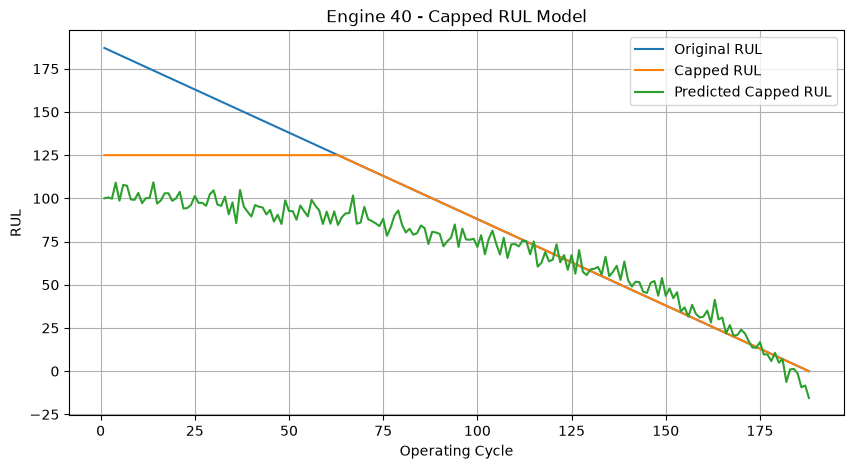

In [20]:
capped_results = val_data.copy()

capped_results["predicted_RUL"] = y_val_capped_pred
engine = capped_results[
    capped_results["engine_id"] == 40
]
plt.figure(figsize=(10, 5))

plt.plot(
    engine["cycle"],
    engine["RUL"],
    label="Original RUL"
)

plt.plot(
    engine["cycle"],
    engine["RUL_capped"],
    label="Capped RUL"
)

plt.plot(
    engine["cycle"],
    engine["predicted_RUL"],
    label="Predicted Capped RUL"
)

plt.xlabel("Operating Cycle")
plt.ylabel("RUL")
plt.title("Engine 40 - Capped RUL Model")
plt.legend()
plt.grid()

plt.show()

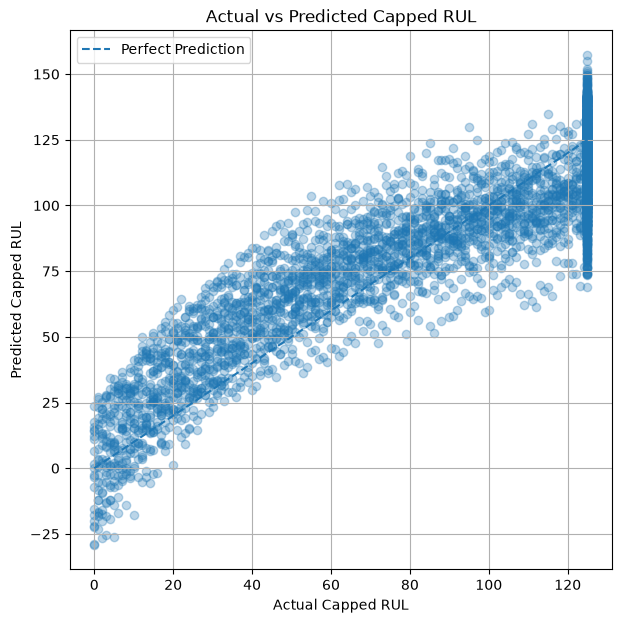

In [21]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_val_capped,
    y_val_capped_pred,
    alpha=0.3
)

plt.plot(
    [0, 125],
    [0, 125],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Capped RUL")
plt.ylabel("Predicted Capped RUL")
plt.title("Actual vs Predicted Capped RUL")

plt.legend()
plt.grid()
plt.show()

Summary:
- the relationship between RUL and sensors is not purely linear
- the model still fails to predict early stages
- once degradation is underway, predictions track RUL better
- negative RUL predictions still occur near failure

We'll try now adding new features before moving on to a new model
- lets begin with rolling average

In [28]:
train_data = train_data.sort_values(
    ["engine_id", "cycle"]
).copy()

val_data = val_data.sort_values(
    ["engine_id", "cycle"]
).copy()

for sensor in selected_sensors:

    # 5-cycle rolling average
    train_data[f"{sensor}_roll5"] = (
        train_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

    val_data[f"{sensor}_roll5"] = (
        val_data
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

    # Change compared with 5 cycles ago
    train_data[f"{sensor}_change5"] = (
        train_data
        .groupby("engine_id")[sensor]
        .diff(5)
        .fillna(0)
    )

    val_data[f"{sensor}_change5"] = (
        val_data
        .groupby("engine_id")[sensor]
        .diff(5)
        .fillna(0)
    )

now add "Change over the last 5 cycles"

In [29]:
features_new = (
    ["cycle"]
    + selected_sensors
    + [f"{sensor}_roll5" for sensor in selected_sensors]
    + [f"{sensor}_change5" for sensor in selected_sensors]
)

now lets test and check MAE

In [30]:
X_train_new = train_data[features_new]
X_val_new = val_data[features_new]

y_train_new = train_data["RUL_capped"]
y_val_new = val_data["RUL_capped"]

In [31]:
scaler_new = StandardScaler()

X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_val_new_scaled = scaler_new.transform(X_val_new)

model_new = LinearRegression()

model_new.fit(
    X_train_new_scaled,
    y_train_new
)

y_train_new_pred = model_new.predict(
    X_train_new_scaled
)

y_val_new_pred = model_new.predict(
    X_val_new_scaled
)
train_mae_new = mean_absolute_error(
    y_train_new,
    y_train_new_pred
)

val_mae_new = mean_absolute_error(
    y_val_new,
    y_val_new_pred
)

train_rmse_new = root_mean_squared_error(
    y_train_new,
    y_train_new_pred
)

val_rmse_new = root_mean_squared_error(
    y_val_new,
    y_val_new_pred
)

In [32]:
print("Training MAE:", train_mae_new)
print("Validation MAE:", val_mae_new)

print("Training RMSE:", train_rmse_new)
print("Validation RMSE:", val_rmse_new)

Training MAE: 16.54305543277053
Validation MAE: 14.360121990518463
Training RMSE: 20.222223275515706
Validation RMSE: 17.69070398345409


summary:
adding recent history to sensors helped but only very slightly.
so the lack of temporal features wasn't the problem, but probably the linear regression limitation is the actual problem, since the relationship seems Non-linear between sensors and RUL.

NOW, let's move to a new model -> DECISION TREE 